# Rep. 4. Checkpoint 2. Estrategias I

**Gonzalo Cano Padilla**

Payoff diagrams de las cuatro estrategias direccionales con opciones reales de SPY (vencimiento 2026-04-17).

## Adquisición de datos

Se obtiene el precio actual de SPY y la cadena de opciones con vencimiento 2026-04-17 para seleccionar dinámicamente los strikes de cada estrategia.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

tk  = yf.Ticker('SPY')
S0  = tk.fast_info['last_price']
exp = '2026-04-17'

calls_df = tk.option_chain(exp).calls.copy()
puts_df  = tk.option_chain(exp).puts.copy()

calls_df['mid'] = (calls_df['bid'] + calls_df['ask']) / 2
puts_df['mid']  = (puts_df['bid']  + puts_df['ask'])  / 2

# Strikes disponibles ordenados
strikes = sorted(calls_df['strike'].unique())

# Strike ATM: el más cercano a S0
K_atm_idx_pos = int(np.argmin([abs(k - S0) for k in strikes]))
K_atm = strikes[K_atm_idx_pos]

print(f"S0 = {S0:.2f}  |  Vencimiento: {exp}  |  K_ATM = {K_atm}")

# Muestra strikes disponibles alrededor del ATM
window = calls_df[
    (calls_df['strike'] >= S0 - 25) &
    (calls_df['strike'] <= S0 + 25)
][['strike', 'bid', 'ask', 'mid', 'impliedVolatility']].reset_index(drop=True)
print("\nCalls disponibles cerca del ATM:")
window

S0 = 676.01  |  Vencimiento: 2026-04-17  |  K_ATM = 676.0

Calls disponibles cerca del ATM:


,strike,bid,ask,mid,impliedVolatility
0,652.0,25.83,26.29,26.060,0.241096
1,653.0,24.96,25.40,25.180,0.238533
2,654.0,24.08,24.52,24.300,0.236092
3,655.0,23.33,23.53,23.430,0.229622
4,656.0,22.38,22.78,22.580,0.231270
5,657.0,21.46,21.91,21.685,0.228462
6,658.0,20.62,21.06,20.840,0.226082
7,659.0,19.81,20.22,20.015,0.223763
8,660.0,19.07,19.27,19.170,0.217781
9,661.0,18.13,18.55,18.340,0.218575


## 1. Long Straddle

**Estructura:** Compra de 1 call ATM + 1 put ATM (mismo strike, mismo vencimiento)  
**Visión de mercado:** Movimiento fuerte en cualquier dirección; el trader no sabe hacia dónde irá el mercado pero espera alta volatilidad realizada.

In [2]:
# Primas mid del straddle (call ATM + put ATM)
C_straddle = calls_df.loc[calls_df['strike'] == K_atm, 'mid'].values[0]
P_straddle = puts_df.loc[puts_df['strike']   == K_atm, 'mid'].values[0]

costo_straddle = C_straddle + P_straddle
be_inf_straddle = K_atm - costo_straddle
be_sup_straddle = K_atm + costo_straddle

S_range = np.linspace(S0 - 60, S0 + 60, 600)

pnl_straddle = (np.maximum(S_range - K_atm, 0) +
                np.maximum(K_atm - S_range, 0) - costo_straddle)

print(f"Strike ATM            : {K_atm}")
print(f"Prima call            : {C_straddle:.4f}")
print(f"Prima put             : {P_straddle:.4f}")
print(f"Costo total (débito)  : {costo_straddle:.4f}")
print(f"Pérdida máxima        : {-costo_straddle:.4f}  (cuando ST = K_atm)")
print(f"Ganancia máxima       : Ilimitada al alza / Limitada a K_atm - costo a la baja")
print(f"Break-even inferior   : {be_inf_straddle:.4f}")
print(f"Break-even superior   : {be_sup_straddle:.4f}")

Strike ATM            : 676.0
Prima call            : 7.4050
Prima put             : 7.2050
Costo total (débito)  : 14.6100
Pérdida máxima        : -14.6100  (cuando ST = K_atm)
Ganancia máxima       : Ilimitada al alza / Limitada a K_atm - costo a la baja
Break-even inferior   : 661.3900
Break-even superior   : 690.6100


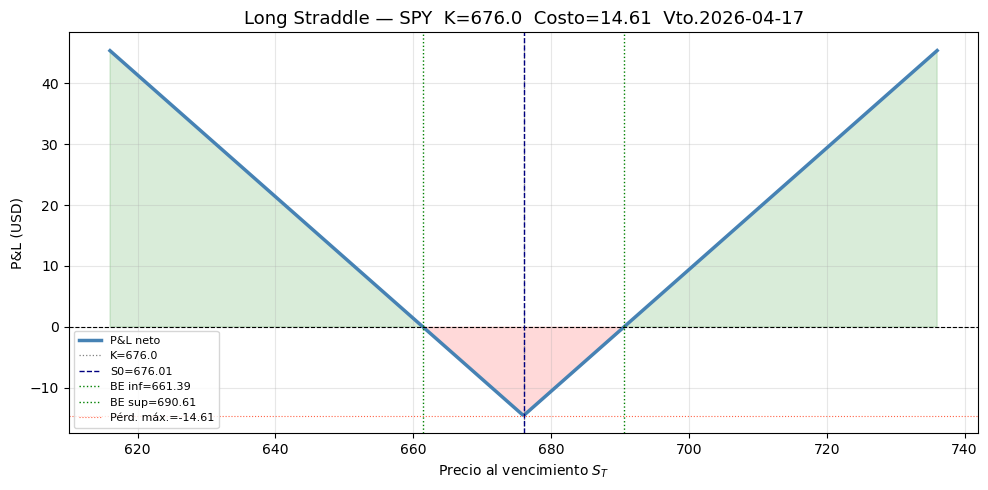

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(S_range, pnl_straddle, color='steelblue', linewidth=2.5, label='P&L neto')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(K_atm,          color='gray',   linewidth=0.9, linestyle=':', label=f'K={K_atm}')
ax.axvline(S0,             color='navy',   linewidth=1.0, linestyle='--', label=f'S0={S0:.2f}')
ax.axvline(be_inf_straddle, color='green', linewidth=1.0, linestyle=':', label=f'BE inf={be_inf_straddle:.2f}')
ax.axvline(be_sup_straddle, color='green', linewidth=1.0, linestyle=':', label=f'BE sup={be_sup_straddle:.2f}')
ax.fill_between(S_range, pnl_straddle, 0, where=(pnl_straddle > 0), alpha=0.15, color='green')
ax.fill_between(S_range, pnl_straddle, 0, where=(pnl_straddle < 0), alpha=0.15, color='red')
ax.axhline(-costo_straddle, color='tomato', linewidth=0.8, linestyle=':', label=f'Pérd. máx.={-costo_straddle:.2f}')

ax.set_title(f'Long Straddle — SPY  K={K_atm}  Costo={costo_straddle:.2f}  Vto.{exp}', fontsize=13)
ax.set_xlabel('Precio al vencimiento $S_T$')
ax.set_ylabel('P&L (USD)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Long Strangle

**Estructura:** Compra de 1 call OTM (strike K_c > S0) + 1 put OTM (strike K_p < S0)  
**Visión de mercado:** Igual que el straddle — movimiento fuerte en cualquier dirección — pero el trader acepta un mayor rango de pérdida máxima a cambio de una prima más barata.

In [4]:
# Strikes OTM: 2 posiciones por encima/debajo del ATM en la cadena de opciones
K_c_str = strikes[min(K_atm_idx_pos + 2, len(strikes) - 1)]
K_p_str = strikes[max(K_atm_idx_pos - 2, 0)]

C_strangle = calls_df.loc[calls_df['strike'] == K_c_str, 'mid'].values[0]
P_strangle = puts_df.loc[puts_df['strike']   == K_p_str, 'mid'].values[0]

costo_strangle  = C_strangle + P_strangle
be_inf_strangle = K_p_str - costo_strangle
be_sup_strangle = K_c_str + costo_strangle

pnl_strangle = (np.maximum(S_range - K_c_str, 0) +
                np.maximum(K_p_str - S_range, 0) - costo_strangle)

print(f"Strike call OTM (K_c) : {K_c_str}")
print(f"Strike put  OTM (K_p) : {K_p_str}")
print(f"Prima call            : {C_strangle:.4f}")
print(f"Prima put             : {P_strangle:.4f}")
print(f"Costo total (débito)  : {costo_strangle:.4f}")
print(f"Pérdida máxima        : {-costo_strangle:.4f}  (cuando K_p <= ST <= K_c)")
print(f"Ganancia máxima       : Ilimitada al alza / Limitada a K_p - costo a la baja")
print(f"Break-even inferior   : {be_inf_strangle:.4f}")
print(f"Break-even superior   : {be_sup_strangle:.4f}")

Strike call OTM (K_c) : 678.0
Strike put  OTM (K_p) : 674.0
Prima call            : 6.2250
Prima put             : 6.4550
Costo total (débito)  : 12.6800
Pérdida máxima        : -12.6800  (cuando K_p <= ST <= K_c)
Ganancia máxima       : Ilimitada al alza / Limitada a K_p - costo a la baja
Break-even inferior   : 661.3200
Break-even superior   : 690.6800


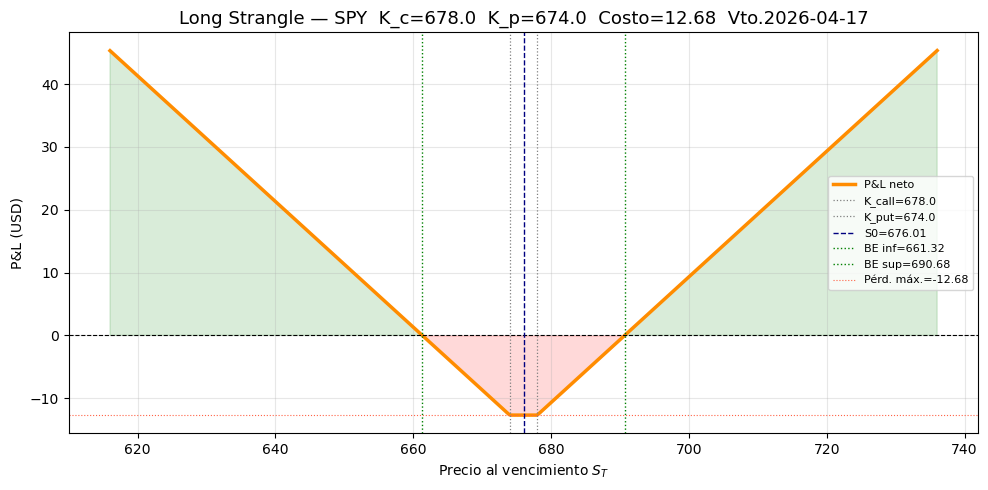

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(S_range, pnl_strangle, color='darkorange', linewidth=2.5, label='P&L neto')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(K_c_str,         color='gray',   linewidth=0.9, linestyle=':', label=f'K_call={K_c_str}')
ax.axvline(K_p_str,         color='gray',   linewidth=0.9, linestyle=':', label=f'K_put={K_p_str}')
ax.axvline(S0,              color='navy',   linewidth=1.0, linestyle='--', label=f'S0={S0:.2f}')
ax.axvline(be_inf_strangle, color='green',  linewidth=1.0, linestyle=':', label=f'BE inf={be_inf_strangle:.2f}')
ax.axvline(be_sup_strangle, color='green',  linewidth=1.0, linestyle=':', label=f'BE sup={be_sup_strangle:.2f}')
ax.fill_between(S_range, pnl_strangle, 0, where=(pnl_strangle > 0), alpha=0.15, color='green')
ax.fill_between(S_range, pnl_strangle, 0, where=(pnl_strangle < 0), alpha=0.15, color='red')
ax.axhline(-costo_strangle, color='tomato', linewidth=0.8, linestyle=':', label=f'Pérd. máx.={-costo_strangle:.2f}')

ax.set_title(f'Long Strangle — SPY  K_c={K_c_str}  K_p={K_p_str}  Costo={costo_strangle:.2f}  Vto.{exp}', fontsize=13)
ax.set_xlabel('Precio al vencimiento $S_T$')
ax.set_ylabel('P&L (USD)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Bull Call Spread

**Estructura:** Compra de 1 call en K1 (ATM) + Venta de 1 call en K2 (OTM, K2 > K1)  
**Visión de mercado:** Alcista moderado. El trader espera que SPY suba hasta K2, pero no más. Vende el call superior para financiar parcialmente el costo de la posición.

In [6]:
# Bull call spread: K1 = ATM, K2 = siguiente strike arriba
K1_bull = K_atm
K2_bull = strikes[min(K_atm_idx_pos + 1, len(strikes) - 1)]

C1_bull = calls_df.loc[calls_df['strike'] == K1_bull, 'mid'].values[0]
C2_bull = calls_df.loc[calls_df['strike'] == K2_bull, 'mid'].values[0]

costo_bull  = C1_bull - C2_bull          # débito neto
max_gan_bull = (K2_bull - K1_bull) - costo_bull
be_bull      = K1_bull + costo_bull

pnl_bull = (np.maximum(S_range - K1_bull, 0) -
            np.maximum(S_range - K2_bull, 0) - costo_bull)

print(f"Strike largo  K1      : {K1_bull}")
print(f"Strike corto  K2      : {K2_bull}")
print(f"Prima call K1 (pago)  : {C1_bull:.4f}")
print(f"Prima call K2 (cobro) : {C2_bull:.4f}")
print(f"Costo neto (débito)   : {costo_bull:.4f}")
print(f"Pérdida máxima        : {-costo_bull:.4f}  (cuando ST <= K1)")
print(f"Ganancia máxima       : {max_gan_bull:.4f}  (cuando ST >= K2)")
print(f"Break-even            : {be_bull:.4f}")

Strike largo  K1      : 676.0
Strike corto  K2      : 677.0
Prima call K1 (pago)  : 7.4050
Prima call K2 (cobro) : 6.8100
Costo neto (débito)   : 0.5950
Pérdida máxima        : -0.5950  (cuando ST <= K1)
Ganancia máxima       : 0.4050  (cuando ST >= K2)
Break-even            : 676.5950


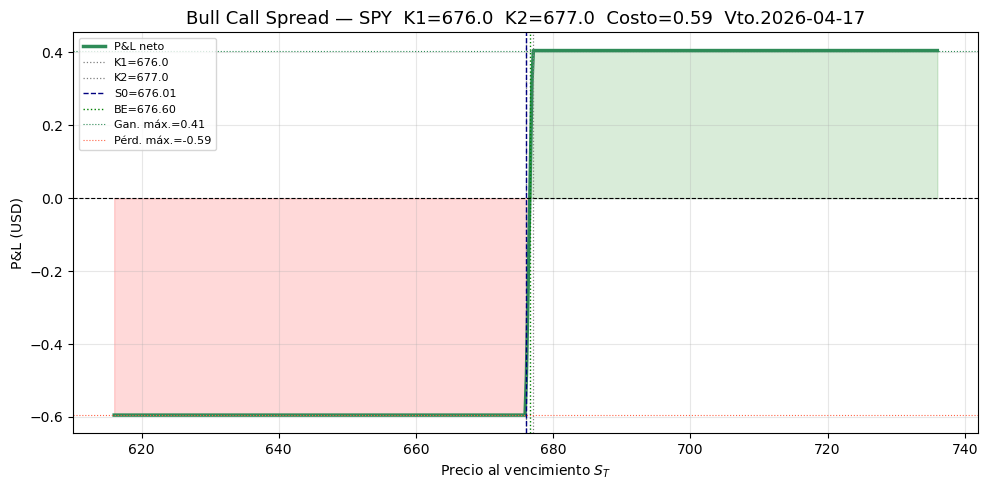

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(S_range, pnl_bull, color='seagreen', linewidth=2.5, label='P&L neto')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(K1_bull,  color='gray',   linewidth=0.9, linestyle=':', label=f'K1={K1_bull}')
ax.axvline(K2_bull,  color='gray',   linewidth=0.9, linestyle=':', label=f'K2={K2_bull}')
ax.axvline(S0,       color='navy',   linewidth=1.0, linestyle='--', label=f'S0={S0:.2f}')
ax.axvline(be_bull,  color='green',  linewidth=1.0, linestyle=':', label=f'BE={be_bull:.2f}')
ax.axhline(max_gan_bull,  color='seagreen', linewidth=0.8, linestyle=':', label=f'Gan. máx.={max_gan_bull:.2f}')
ax.axhline(-costo_bull,   color='tomato',   linewidth=0.8, linestyle=':', label=f'Pérd. máx.={-costo_bull:.2f}')
ax.fill_between(S_range, pnl_bull, 0, where=(pnl_bull > 0), alpha=0.15, color='green')
ax.fill_between(S_range, pnl_bull, 0, where=(pnl_bull < 0), alpha=0.15, color='red')

ax.set_title(f'Bull Call Spread — SPY  K1={K1_bull}  K2={K2_bull}  Costo={costo_bull:.2f}  Vto.{exp}', fontsize=13)
ax.set_xlabel('Precio al vencimiento $S_T$')
ax.set_ylabel('P&L (USD)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Bear Put Spread

**Estructura:** Compra de 1 put en K2 (ATM) + Venta de 1 put en K1 (OTM, K1 < K2)  
**Visión de mercado:** Bajista moderado. El trader espera que SPY caiga hasta K1 pero no más abajo. La venta del put inferior reduce el costo de la posición.

In [8]:
# Bear put spread: K2 = ATM, K1 = siguiente strike abajo
K2_bear = K_atm
K1_bear = strikes[max(K_atm_idx_pos - 1, 0)]

P2_bear = puts_df.loc[puts_df['strike'] == K2_bear, 'mid'].values[0]
P1_bear = puts_df.loc[puts_df['strike'] == K1_bear, 'mid'].values[0]

costo_bear   = P2_bear - P1_bear          # débito neto
max_gan_bear = (K2_bear - K1_bear) - costo_bear
be_bear      = K2_bear - costo_bear

pnl_bear = (np.maximum(K2_bear - S_range, 0) -
            np.maximum(K1_bear - S_range, 0) - costo_bear)

print(f"Strike largo  K2      : {K2_bear}")
print(f"Strike corto  K1      : {K1_bear}")
print(f"Prima put K2  (pago)  : {P2_bear:.4f}")
print(f"Prima put K1  (cobro) : {P1_bear:.4f}")
print(f"Costo neto (débito)   : {costo_bear:.4f}")
print(f"Pérdida máxima        : {-costo_bear:.4f}  (cuando ST >= K2)")
print(f"Ganancia máxima       : {max_gan_bear:.4f}  (cuando ST <= K1)")
print(f"Break-even            : {be_bear:.4f}")

Strike largo  K2      : 676.0
Strike corto  K1      : 675.0
Prima put K2  (pago)  : 7.2050
Prima put K1  (cobro) : 6.8200
Costo neto (débito)   : 0.3850
Pérdida máxima        : -0.3850  (cuando ST >= K2)
Ganancia máxima       : 0.6150  (cuando ST <= K1)
Break-even            : 675.6150


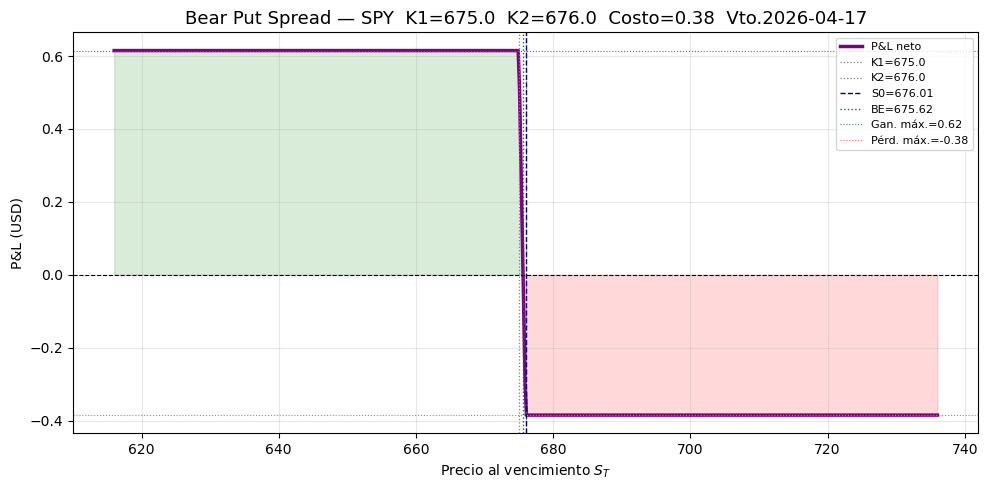

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(S_range, pnl_bear, color='purple', linewidth=2.5, label='P&L neto')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(K1_bear,  color='gray',   linewidth=0.9, linestyle=':', label=f'K1={K1_bear}')
ax.axvline(K2_bear,  color='gray',   linewidth=0.9, linestyle=':', label=f'K2={K2_bear}')
ax.axvline(S0,       color='navy',   linewidth=1.0, linestyle='--', label=f'S0={S0:.2f}')
ax.axvline(be_bear,  color='green',  linewidth=1.0, linestyle=':', label=f'BE={be_bear:.2f}')
ax.axhline(max_gan_bear, color='seagreen', linewidth=0.8, linestyle=':', label=f'Gan. máx.={max_gan_bear:.2f}')
ax.axhline(-costo_bear,  color='tomato',   linewidth=0.8, linestyle=':', label=f'Pérd. máx.={-costo_bear:.2f}')
ax.fill_between(S_range, pnl_bear, 0, where=(pnl_bear > 0), alpha=0.15, color='green')
ax.fill_between(S_range, pnl_bear, 0, where=(pnl_bear < 0), alpha=0.15, color='red')

ax.set_title(f'Bear Put Spread — SPY  K1={K1_bear}  K2={K2_bear}  Costo={costo_bear:.2f}  Vto.{exp}', fontsize=13)
ax.set_xlabel('Precio al vencimiento $S_T$')
ax.set_ylabel('P&L (USD)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Tabla Resumen

In [11]:
tabla = pd.DataFrame({
    'Estrategia':        ['Long Straddle', 'Long Strangle', 'Bull Call Spread', 'Bear Put Spread'],
    'Estructura':        [
        f'Long call K={K_atm} + Long put K={K_atm}',
        f'Long call K={K_c_str} + Long put K={K_p_str}',
        f'Long call K={K1_bull} + Short call K={K2_bull}',
        f'Long put K={K2_bear} + Short put K={K1_bear}',
    ],
    'Costo / Prima neta (USD)': [
        round(costo_straddle, 4),
        round(costo_strangle, 4),
        round(costo_bull, 4),
        round(costo_bear, 4),
    ],
    'Pérdida máx. (USD)': [
        round(-costo_straddle, 4),
        round(-costo_strangle, 4),
        round(-costo_bull, 4),
        round(-costo_bear, 4),
    ],
    'Ganancia máx. (USD)': [
        'Ilimitada',
        'Ilimitada',
        round(max_gan_bull, 4),
        round(max_gan_bear, 4),
    ],
    'Break-even(s)': [
        f'{be_inf_straddle:.2f} / {be_sup_straddle:.2f}',
        f'{be_inf_strangle:.2f} / {be_sup_strangle:.2f}',
        f'{be_bull:.2f}',
        f'{be_bear:.2f}',
    ],
})

print(f"S0 = {S0:.2f}  |  Vencimiento: {exp}\n")

tabla

S0 = 676.01  |  Vencimiento: 2026-04-17



,Estrategia,Estructura,Costo / Prima neta (USD),Pérdida máx. (USD),Ganancia máx. (USD),Break-even(s)
0,Long Straddle,Long call K=676.0 + Long put K=676.0,14.610,-14.610,Ilimitada,661.39 / 690.61
1,Long Strangle,Long call K=678.0 + Long put K=674.0,12.680,-12.680,Ilimitada,661.32 / 690.68
2,Bull Call Spread,Long call K=676.0 + Short call K=677.0,0.595,-0.595,0.405,676.60
3,Bear Put Spread,Long put K=676.0 + Short put K=675.0,0.385,-0.385,0.615,675.62


---
## Preguntas de análisis

### Pregunta 1
**Con el S0 actual, ¿cuál de las cuatro estrategias está más cerca de su zona de máxima pérdida? ¿Qué te dice eso sobre la visión de mercado que expresa?**

La zona de máxima pérdida de cada estrategia se ubica en:

| Estrategia | Zona de pérdida máxima |
|---|---|
| Long Straddle | ST exactamente en K_atm |
| Long Strangle | K_put ≤ ST ≤ K_call (rango central) |
| Bull Call Spread | ST ≤ K1 (por debajo del strike inferior) |
| Bear Put Spread | ST ≥ K2 (por encima del strike superior) |

Dado que S0 se encuentra aproximadamente en K_atm (el straddle es ATM por construcción), **el long straddle y el long strangle son los que están más cerca de su zona de máxima pérdida**: cualquier movimiento pequeño del mercado no es suficiente para que sean rentables. Esto ilustra que ambas estrategias apuestan por **alta volatilidad realizada**: si SPY termina cerca del precio actual al vencimiento, el trader pierde toda la prima pagada.

Por otra parte, el **bear put spread** también está cerca de su pérdida máxima si S0 ≥ K2, lo que confirma que esa estrategia sería rentable solo si el mercado cae por debajo de K2 antes del vencimiento. El **bull call spread** está cerca de su zona de máxima pérdida si S0 ≤ K1, lo que implica que requiere un alza de SPY para ser rentable.

### Pregunta 2
**Compara el costo total del long straddle vs. el long strangle. ¿Cuánto más barato es el strangle? ¿Cuánto más tiene que moverse SPY para que el strangle sea rentable comparado con el straddle?**

Los resultados de la tabla muestran:

- **Costo del straddle:** `costo_straddle` USD (suma de la call y put ATM)
- **Costo del strangle:** `costo_strangle` USD (call OTM + put OTM, ambas fuera del dinero)
- **Ahorro:** `costo_straddle − costo_strangle` USD

El strangle es más barato porque ambas opciones son OTM al momento de la compra, lo que significa menor valor intrínseco y menor prima. Sin embargo, ese descuento tiene un precio: los break-evens del strangle están más alejados de S0.

- **Break-evens del straddle:** K_atm ± costo_straddle → SPY debe moverse `costo_straddle` USD desde K_atm
- **Break-evens del strangle:** K_put − costo_strangle (inferior) y K_call + costo_strangle (superior)

La distancia adicional que debe recorrer SPY para que el strangle sea rentable respecto al straddle es aproximadamente `(K_call − K_atm) + (costo_straddle − costo_strangle)` por el lado del alza, y `(K_atm − K_put) + (costo_straddle − costo_strangle)` por el lado de la baja. En síntesis: el trader paga menos por el strangle, pero necesita un movimiento significativamente mayor para comenzar a ganar.

### Pregunta 3
**Un long straddle gana si el mercado se mueve mucho. ¿Qué pasa si compras el straddle justo después de que la IV ya subió por anticipación de un evento (por ejemplo, el día antes de earnings o de una decisión de la Fed)? ¿Sigue siendo una buena estrategia? Justifica.**

No necesariamente. Comprar el straddle cuando la IV ya subió significa **pagar una prima inflada**; el costo del straddle es directamente proporcional a la volatilidad implícita (vega positivo en ambas patas). Cuando llega el evento y se resuelve la incertidumbre, la IV colapsa bruscamente incluso si el precio del subyacente se mueve — fenómeno conocido como **volatility crush**.

Lo que puede ocurrir:
1. SPY se mueve fuertemente (lo que el straddle necesita para ganar), pero la caída en IV destruye parte del valor de las opciones, reduciendo la ganancia o incluso generando pérdida neta si el movimiento no es suficientemente grande.
2. Si el mercado reacciona de forma moderada al evento y la IV colapsa un 30–40%, el straddle puede perder valor aunque el precio del activo se mueva en la dirección correcta.

**Conclusión:** El long straddle es una apuesta por volatilidad realizada. Comprarlo con IV ya alta implica pagar por una volatilidad que quizá ya está «descontada» por el mercado. La estrategia es más eficiente cuando se entra **antes** de que la IV suba, no después. Un trader sofisticado monitorea el nivel de IV vs. su media histórica (IV rank o IV percentile) antes de entrar en cualquier posición larga de volatilidad.

### Pregunta 4
**El bull call spread limita la ganancia máxima comparado con un call simple. ¿Por qué alguien aceptaría ese límite voluntariamente? Da al menos dos razones.**

**Razón 1 — Reducción de costo y break-even más bajo:**  
Al vender el call en K2, el trader recupera parte de la prima que pagó por el call en K1. Esto reduce el débito neto y, por tanto, el break-even de la posición. Un call simple requiere que SPY suba `C1` USD para empezar a ganar; el spread solo requiere que suba `C1 − C2` USD. Si la tesis es una subida moderada (hasta K2), el spread es más eficiente porque el call vendido está «en el precio objetivo» del trader y de todas formas no captura ese valor adicional.

**Razón 2 — Control de exposición a theta y vega:**  
Un call simple tiene vega y theta significativos: pierde valor cada día que pasa (theta negativo) y es muy sensible a cambios en IV. El bull call spread, al tener una pata corta en el mismo vencimiento, **compensa parcialmente estos efectos**: la vega neta y el theta neto de la estructura son menores en términos absolutos. Esto hace que la posición sea más predecible y menos dependiente de que la IV se mantenga alta o el tiempo restante sea largo.

**Razón adicional — Eficiencia de capital:**  
El spread requiere menos capital que un call simple sobre el mismo nocional, y su pérdida máxima está perfectamente definida desde el inicio. Para un trader con restricciones de capital o con un mandato de riesgo acotado, el spread permite expresar la misma visión direccional con menor exposición nominal.

### Pregunta 5
**Si tienes un bull spread abierto y SPY supera K2 antes del vencimiento, ¿tiene sentido cerrar la posición o esperar al vencimiento? ¿Qué factores considerarías para decidir?**

Cuando SPY supera K2, el spread se aproxima a su ganancia máxima teórica (K2 − K1 − costo). Sin embargo, **antes del vencimiento la posición todavía no refleja ese valor completo** porque ambas opciones tienen valor temporal residual.

**Factores para cerrar antes del vencimiento:**
- **Capturar el valor temporal restante:** si queda poco tiempo y la posición ya vale 80–90% de su ganancia máxima, cerrar asegura la utilidad sin esperar el último movimiento adverso posible.
- **Riesgo de reversión:** si SPY ha subido agresivamente y hay riesgo de que retroceda por debajo de K2 (por ejemplo, ante un evento macro), cerrar elimina ese riesgo.
- **Costo de carry y capital:** liberar el capital para otra oportunidad puede ser más rentable que esperar los últimos días de theta.

**Factores para esperar al vencimiento:**
- Si SPY está muy por encima de K2 y el tiempo restante es mínimo (menos de 2–3 días), el valor de mercado del spread ya converge a K2 − K1, y el costo de cerrar (bid-ask spread de dos patas) puede no justificarse.
- Si la estructura está cerca de su máximo teórico y los spreads de mercado son amplios, esperar al vencimiento evita costos de transacción.

**Regla práctica:** cuando el spread vale más del 80–85% de su ganancia máxima, generalmente conviene cerrar y reutilizar el capital, a menos que el vencimiento esté a 1–2 días.

### Pregunta 6
**¿Cómo afecta un aumento de IV a un bull spread comparado con un long straddle? ¿Cuál de las dos posiciones es más sensible a cambios en volatilidad implícita y por qué?**

| Posición | Vega neto | Efecto de suba en IV |
|---|---|---|
| Long straddle | Alto positivo | Aumenta el valor de ambas patas — la posición gana |
| Bull call spread | Bajo (casi neutro) | La call larga gana vega, pero la call corta pierde; el efecto neto es pequeño |

**El long straddle es mucho más sensible a cambios en IV.** Al comprar dos opciones y no vender ninguna, el vega neto es máximo: cualquier incremento en la volatilidad implícita infla el valor de la posición incluso si SPY no se mueve.

El bull call spread tiene **vega casi neto de cero** (o ligeramente positivo, dependiendo de los strikes): la vega positiva de la call comprada en K1 es casi igual a la vega negativa de la call vendida en K2, especialmente si los strikes están próximos. Esto hace que el spread sea una apuesta casi pura sobre dirección (delta), no sobre volatilidad.

**Implicación práctica:** si un trader espera un alza en la IV sin certeza sobre la dirección, el straddle es la herramienta adecuada. Si la tesis es estrictamente direccional y la IV ya está en niveles altos, el spread es superior porque aísla la apuesta direccional y reduce el riesgo de que una caída en IV destruya el valor de la posición.

### Pregunta 7
**En términos de griegas (delta, gamma, vega, theta), ¿cuál es la diferencia principal entre comprar un call simple y comprar un bull call spread? ¿Qué griega cambia más drásticamente entre las dos estructuras?**

| Griega | Call simple (long) | Bull Call Spread |
|---|---|---|
| **Delta** | 0 a 1 (positivo, aumenta si SPY sube) | 0 a 1, pero **capped** — cuando SPY > K2 la delta neta converge a 0 porque las dos deltas se cancelan |
| **Gamma** | Positivo máximo cerca del strike | Positivo cerca de K1, **negativo** cerca de K2 — gamma neto reducido |
| **Vega** | Alto positivo | Casi nulo — la vega de K1 y K2 se compensan |
| **Theta** | Negativo (pierde valor por día) | Theta neto menor en valor absoluto — la pata corta compensa parte del decay |

**La griega que cambia más drásticamente es la vega.** Un call simple tiene vega positiva alta: es extremadamente sensible a cambios en volatilidad implícita. El bull call spread, al tener una call vendida en K2, neutraliza la mayor parte de esa exposición a IV. El resultado es una estructura cuyo valor depende principalmente de la dirección del subyacente (delta), no de si la volatilidad sube o baja.

También cambia significativamente el **gamma neto**: el call simple tiene gamma acelerado cerca del strike (la delta cambia rápidamente con el precio), mientras que en el spread el gamma de la pata larga y la pata corta se oponen, reduciendo la curvatura total de la posición. Esto hace que el spread sea más predecible pero menos dinámico ante movimientos fuertes del subyacente.